****IMPORTATION ET MISE EN FORME****

In [1]:
# -*- coding: utf-8 -*-
"""
Analyse des données accidentologiques (2016-2026)
====================================================
Ce script :
1. Charge les 10 fichiers XML (un par année) contenant les données
   mensuelles (accidents, tués, blessés).
2. Construit un tableau (DataFrame) unique et propre.
3. Fait une EDA simple (aperçu, stats, valeurs manquantes, doublons).
4. Trace l'évolution des accidents / blessés / morts de 2015 à 2025.

Utilisation :
    python accidents_analyse.py

Placez vos 10 fichiers .xml dans le dossier DATA_DIR ci-dessous
(le nom du fichier doit contenir l'année, ex: "accidents_2016.xml").
"""

import re
import glob
import xml.etree.ElementTree as ET

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 0. CONFIGURATION
# ------------------------------------------------------------------
DATA_DIR = "data\data_mensuelle"          # <-- dossier contenant les 10 fichiers XML
OUTPUT_CSV = "accidents_2015_2025.csv"

# Correspondance mois arabe (dialecte tunisien) -> mois français + numéro
MOIS_MAP = {
    "جانفي":   (1,  "Janvier"),
    "فيفري":   (2,  "Février"),
    "مارس":    (3,  "Mars"),
    "افريل":   (4,  "Avril"),
    "ماي":     (5,  "Mai"),
    "جوان":    (6,  "Juin"),
    "جويلية":  (7,  "Juillet"),
    "اوت":     (8,  "Août"),
    "سبتمبر":  (9,  "Septembre"),
    "اكتوبر":  (10, "Octobre"),
    "نوفمبر":  (11, "Novembre"),
    "ديسمبر":  (12, "Décembre"),
}


# ------------------------------------------------------------------
# 1. LECTURE D'UN FICHIER XML
# ------------------------------------------------------------------
def extraire_annee(nom_fichier: str) -> int:
    """Extrait la première suite de 4 chiffres trouvée dans le nom du fichier."""
    match = re.search(r"(20\d{2})", nom_fichier)
    if not match:
        raise ValueError(f"Impossible de trouver l'année dans : {nom_fichier}")
    return int(match.group(1))


def parser_fichier_xml(chemin: str) -> pd.DataFrame:
    """Lit un fichier XML d'une année et retourne un DataFrame mensuel."""
    annee = extraire_annee(chemin)
    tree = ET.parse(chemin)
    root = tree.getroot()

    lignes = []
    for item in root.findall("item"):
        label_ar = item.findtext("labelle", default="").strip()
        accidents = int(item.findtext("accidents", default=0))
        tues = int(item.findtext("tues", default=0))
        blesses = int(item.findtext("blesses", default=0))

        if label_ar not in MOIS_MAP:
            print(f"  ⚠ Mois non reconnu '{label_ar}' dans {chemin} -> ignoré")
            continue

        mois_num, mois_fr = MOIS_MAP[label_ar]
        lignes.append({
            "Annee": annee,
            "Mois_num": mois_num,
            "Mois": mois_fr,
            "Accidents": accidents,
            "Morts": tues,
            "Blesses": blesses,
        })

    return pd.DataFrame(lignes)


# ------------------------------------------------------------------
# 2. CHARGEMENT DE TOUS LES FICHIERS
# ------------------------------------------------------------------
def charger_tous_les_fichiers(data_dir: str) -> pd.DataFrame:
    fichiers = sorted(glob.glob(f"{data_dir}/*.xml"))
    if not fichiers:
        raise FileNotFoundError(f"Aucun fichier .xml trouvé dans {data_dir}")

    print(f"{len(fichiers)} fichiers trouvés :")
    for f in fichiers:
        print(" -", f)

    dfs = [parser_fichier_xml(f) for f in fichiers]
    df = pd.concat(dfs, ignore_index=True)
    df = df.sort_values(["Annee", "Mois_num"]).reset_index(drop=True)

    # Colonne date (utile pour les graphiques en série temporelle)
    df["Date"] = pd.to_datetime(
        df["Annee"].astype(str) + "-" + df["Mois_num"].astype(str) + "-01"
    )
    return df


# ------------------------------------------------------------------
# 3. EDA SIMPLE
# ------------------------------------------------------------------
def eda_simple(df: pd.DataFrame) -> None:
    print("\n" + "=" * 60)
    print("APERÇU DES DONNÉES")
    print("=" * 60)
    print(df.head(12))

    print("\n--- Infos générales ---")
    print(df.info())

    print("\n--- Statistiques descriptives ---")
    print(df[["Accidents", "Morts", "Blesses"]].describe())

    print("\n--- Valeurs manquantes ---")
    print(df.isna().sum())

    print("\n--- Doublons (Année/Mois) ---")
    doublons = df.duplicated(subset=["Annee", "Mois_num"]).sum()
    print(f"{doublons} doublon(s) trouvé(s)")

    print("\n--- Nombre de mois par année (doit être 12, sauf année en cours) ---")
    print(df.groupby("Annee").size())

    print("\n--- Totaux annuels ---")
    totaux = df.groupby("Annee")[["Accidents", "Morts", "Blesses"]].sum()
    print(totaux)





# ------------------------------------------------------------------
# MAIN
# ------------------------------------------------------------------
if __name__ == "__main__":
    df = charger_tous_les_fichiers(DATA_DIR)

    df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
    print(f"\n✔ Tableau sauvegardé dans : {OUTPUT_CSV}")

    eda_simple(df)

    

11 fichiers trouvés :
 - data\data_mensuelle\mois2015.xml
 - data\data_mensuelle\mois2016.xml
 - data\data_mensuelle\mois2017.xml
 - data\data_mensuelle\mois2018.xml
 - data\data_mensuelle\mois2019.xml
 - data\data_mensuelle\mois2020.xml
 - data\data_mensuelle\mois2021.xml
 - data\data_mensuelle\mois2022.xml
 - data\data_mensuelle\mois2023.xml
 - data\data_mensuelle\mois2024.xml
 - data\data_mensuelle\mois2025.xml

✔ Tableau sauvegardé dans : accidents_2015_2025.csv

APERÇU DES DONNÉES
    Annee  Mois_num       Mois  Accidents  Morts  Blesses       Date
0    2015         1    Janvier        621    102      847 2015-01-01
1    2015         2    Février        544     98      775 2015-02-01
2    2015         3       Mars        583     87      871 2015-03-01
3    2015         4      Avril        620    104      839 2015-04-01
4    2015         5        Mai        700     97     1041 2015-05-01
5    2015         6       Juin        600    129      959 2015-06-01
6    2015         7    Jui

### Lecture des données et première exploration

Dans cette première étape, les fichiers mensuels au format XML sont parcourus puis regroupés dans un seul tableau. Une colonne `Date` est également construite à partir de l’année et du numéro du mois afin de faciliter les analyses chronologiques.

Une première exploration descriptive est ensuite réalisée pour vérifier la structure du jeu de données : aperçu des observations, informations sur les variables, statistiques descriptives des accidents, des décès et des blessés, valeurs manquantes, doublons et nombre de mois disponibles par année.

Cette étape permet ainsi de disposer d’une base unique et structurée avant de commencer l’analyse temporelle de l’accidentologie en Tunisie.

****PRETRAITEMENT****

In [2]:
import pandas as pd

df_csv = pd.read_csv("accidents_2015_2025.csv")

print("Aperçu :")
print(df_csv.head())

print("\nValeurs manquantes par colonne :")
print(df_csv.isna().sum())

print("\nLignes avec au moins une valeur manquante :")
print(df_csv[df_csv.isna().any(axis=1)])

print("\nMois manquants par année (doit être 12 par année) :")
print(df_csv.groupby("Annee")["Mois"].count())

print("\nDoublons (Année/Mois) :")
print(df_csv.duplicated(subset=["Annee", "Mois_num"]).sum())

Aperçu :
   Annee  Mois_num     Mois  Accidents  Morts  Blesses        Date
0   2015         1  Janvier        621    102      847  2015-01-01
1   2015         2  Février        544     98      775  2015-02-01
2   2015         3     Mars        583     87      871  2015-03-01
3   2015         4    Avril        620    104      839  2015-04-01
4   2015         5      Mai        700     97     1041  2015-05-01

Valeurs manquantes par colonne :
Annee        0
Mois_num     0
Mois         0
Accidents    0
Morts        0
Blesses      0
Date         0
dtype: int64

Lignes avec au moins une valeur manquante :
Empty DataFrame
Columns: [Annee, Mois_num, Mois, Accidents, Morts, Blesses, Date]
Index: []

Mois manquants par année (doit être 12 par année) :
Annee
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
Name: Mois, dtype: int64

Doublons (Année/Mois) :
0


### Vérification de la qualité des données

Après la création du fichier consolidé, une seconde vérification est effectuée avant l’analyse. L’objectif est de s’assurer que les données utilisées pour comparer les années et les mois sont complètes et cohérentes.

Les résultats montrent qu’il n’y a **aucune valeur manquante**, que chaque année contient **12 mois** et qu’aucun doublon sur le couple `Année/Mois` n’est détecté. La base peut donc être utilisée pour les analyses temporelles sans traitement supplémentaire des valeurs manquantes ou des doublons.

****EVOLUTION DES ACCIDENTS DURANT DIX ANS****

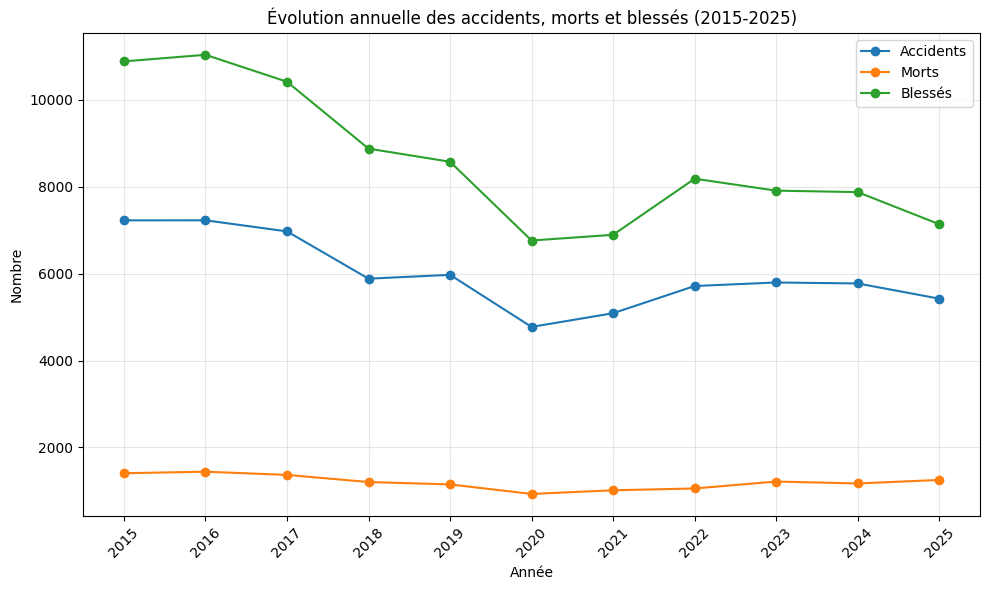

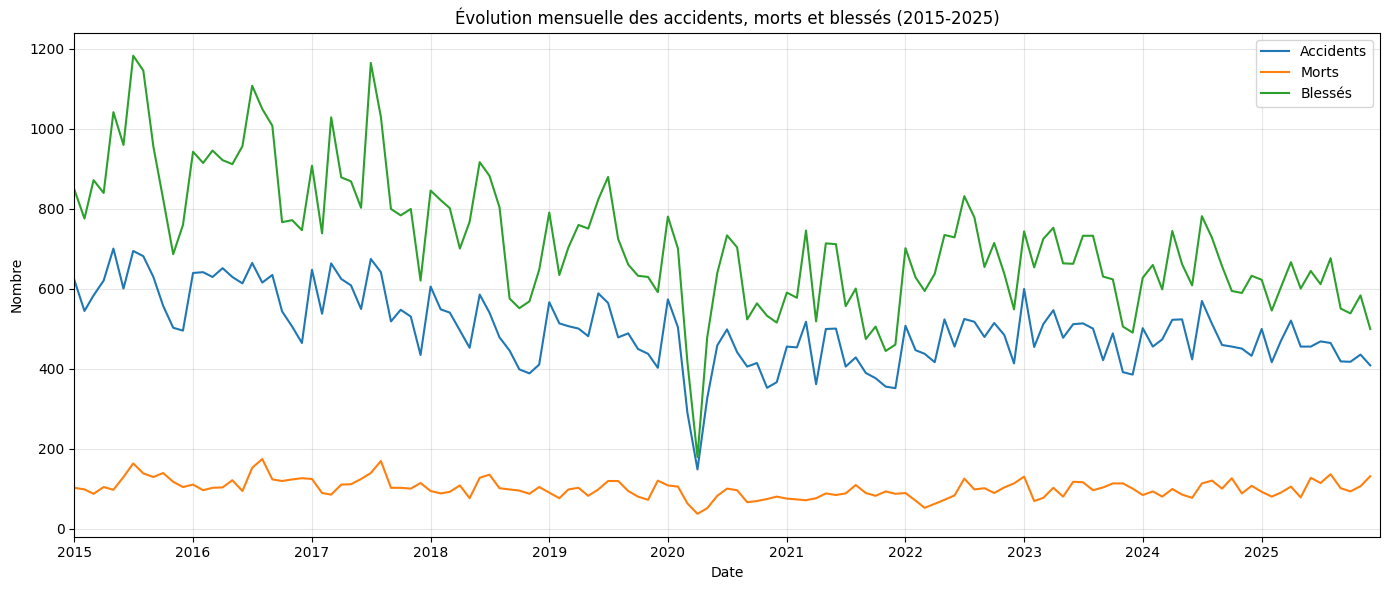

In [3]:
# ------------------------------------------------------------------
# 4. GRAPHIQUE D'ÉVOLUTION
# ------------------------------------------------------------------
def tracer_evolution_annuelle(df: pd.DataFrame) -> None:
    """Courbe de l'évolution annuelle (somme des 12 mois) 2015-2025."""
    totaux = df.groupby("Annee")[["Accidents", "Morts", "Blesses"]].sum()

    plt.figure(figsize=(10, 6))
    plt.plot(totaux.index, totaux["Accidents"], marker="o", label="Accidents")
    plt.plot(totaux.index, totaux["Morts"], marker="o", label="Morts")
    plt.plot(totaux.index, totaux["Blesses"], marker="o", label="Blessés")

    plt.title("Évolution annuelle des accidents, morts et blessés (2015-2025)")
    plt.xlabel("Année")
    plt.ylabel("Nombre")
    plt.xticks(totaux.index, rotation=45)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("evolution_annuelle.png", dpi=150)
    plt.show()


def tracer_evolution_mensuelle(df: pd.DataFrame) -> None:
    """Courbe mensuelle limitée à la période 2015-2025."""
    df = df.loc[df["Annee"].between(2015, 2025)].sort_values("Date").copy()

    if df.empty or df["Annee"].min() != 2015:
        raise ValueError("Le DataFrame doit contenir des données de 2015 à 2025.")

    plt.figure(figsize=(14, 6))
    plt.plot(df["Date"], df["Accidents"], label="Accidents")
    plt.plot(df["Date"], df["Morts"], label="Morts")
    plt.plot(df["Date"], df["Blesses"], label="Blessés")

    plt.title("Évolution mensuelle des accidents, morts et blessés (2015-2025)")
    plt.xlabel("Date")
    plt.ylabel("Nombre")
    plt.xlim(pd.Timestamp("2015-01-01"), pd.Timestamp("2025-12-31"))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("evolution_mensuelle.png", dpi=150)
    plt.show()

tracer_evolution_annuelle(df)
tracer_evolution_mensuelle(df)

### Première analyse de l’évolution temporelle

L’objectif de cette étape est d’observer l’évolution globale de l’accidentologie sur la période 2015–2025.

Deux niveaux d’analyse sont réalisés. D’abord, les valeurs sont agrégées par année afin d’obtenir une vision globale de l’évolution des accidents, des morts et des blessés. Ensuite, les données sont conservées à l’échelle mensuelle afin d’identifier d’éventuelles variations saisonnières ou des ruptures particulières au cours de la période.

La courbe mensuelle permet notamment de repérer plus précisément les fluctuations d’une année à l’autre, tandis que la courbe annuelle facilite l’identification d’une tendance générale.

****HISTOGRAMME DES EVENEMENTS (ANNUEL ET MENSUEL)****

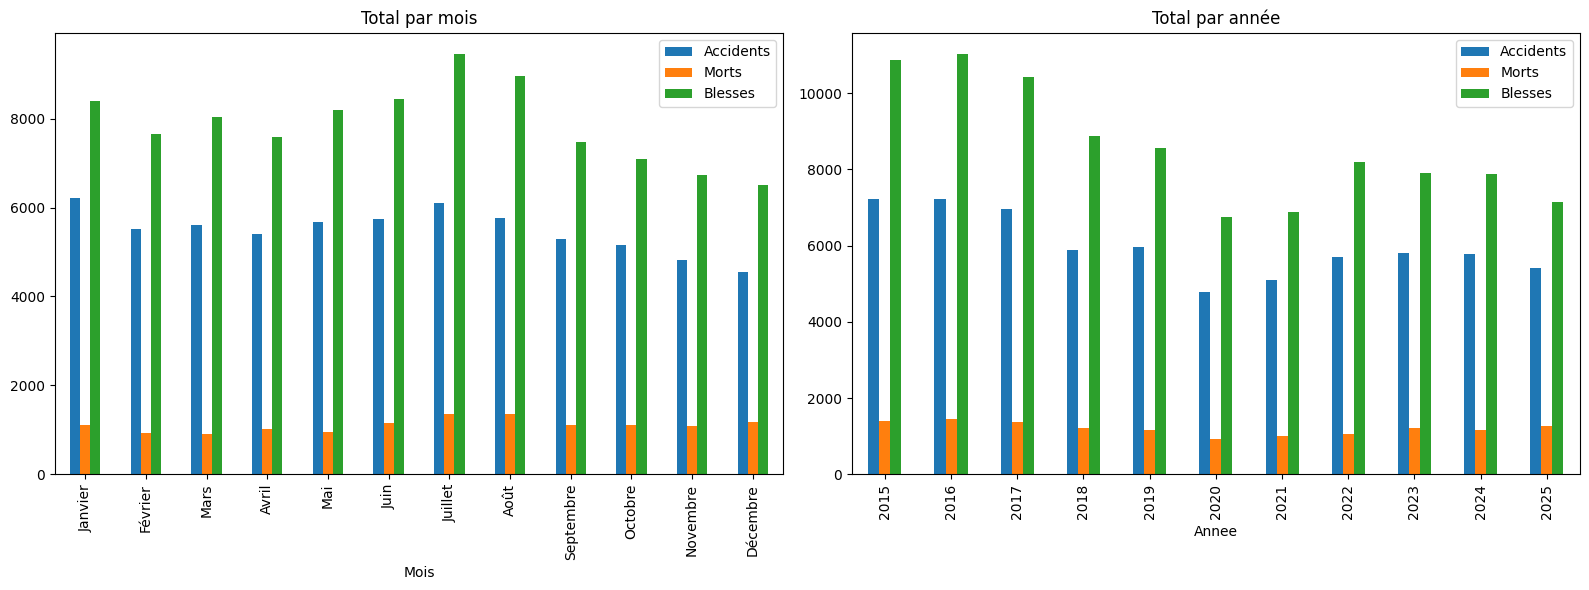

In [4]:
import matplotlib.pyplot as plt

ordre_mois = ["Janvier","Février","Mars","Avril","Mai","Juin",
              "Juillet","Août","Septembre","Octobre","Novembre","Décembre"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df.groupby("Mois")[["Accidents", "Morts", "Blesses"]].sum().reindex(ordre_mois).plot(kind="bar", ax=axes[0])
axes[0].set_title("Total par mois")

df.groupby("Annee")[["Accidents", "Morts", "Blesses"]].sum().plot(kind="bar", ax=axes[1])
axes[1].set_title("Total par année")

plt.tight_layout()
plt.show()

### Comparaison des distributions annuelles et mensuelles

Afin de compléter les courbes précédentes, les données sont agrégées sous forme d’histogrammes selon deux axes : le mois et l’année.

La distribution mensuelle permet de comparer le volume total d’événements observés pour chacun des mois sur l’ensemble de la période 2015–2025. Elle permet notamment de mettre en évidence une concentration plus importante des accidents durant certains mois, en particulier pendant la période estivale.

La distribution annuelle permet quant à elle de visualiser la tendance générale sur la période étudiée. On observe globalement une diminution du nombre d’accidents au fil des années, avec une baisse particulièrement marquée autour de 2020. Cette rupture sera étudiée plus précisément par la suite.

****HISTOGRAMME (PAR SAISON)****

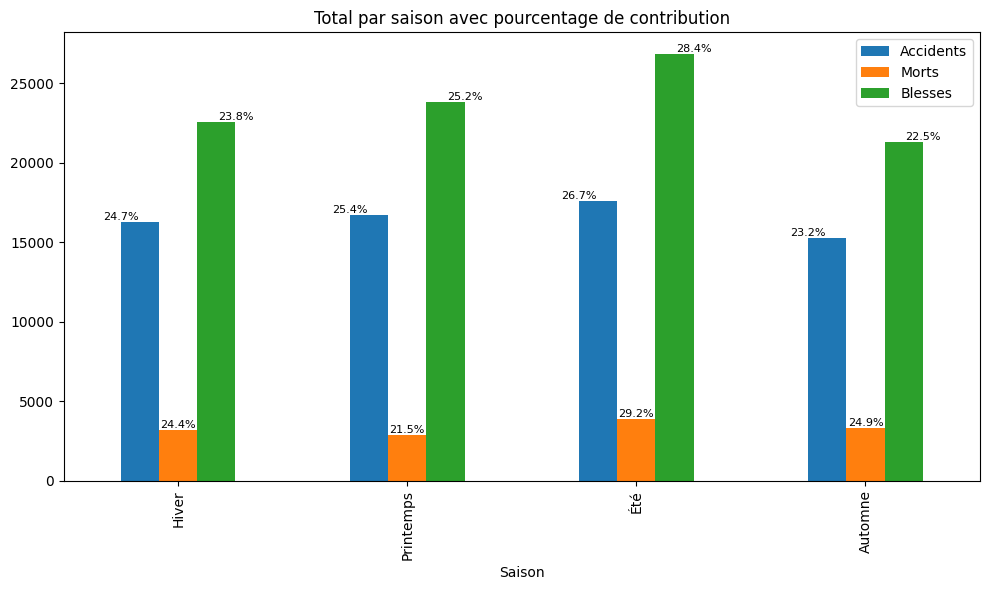

In [5]:
import matplotlib.pyplot as plt

saison_map = {
    "Décembre": "Hiver", "Janvier": "Hiver", "Février": "Hiver",
    "Mars": "Printemps", "Avril": "Printemps", "Mai": "Printemps",
    "Juin": "Été", "Juillet": "Été", "Août": "Été",
    "Septembre": "Automne", "Octobre": "Automne", "Novembre": "Automne",
}
ordre_saisons = ["Hiver", "Printemps", "Été", "Automne"]

df["Saison"] = df["Mois"].map(saison_map)

par_saison = df.groupby("Saison")[["Accidents", "Morts", "Blesses"]].sum().reindex(ordre_saisons)
pourcentages = par_saison.div(par_saison.sum(axis=0), axis=1) * 100

ax = par_saison.plot(kind="bar", figsize=(10, 6))
plt.title("Total par saison avec pourcentage de contribution")

for i, saison in enumerate(par_saison.index):
    for j, col in enumerate(par_saison.columns):
        valeur = par_saison.loc[saison, col]
        pct = pourcentages.loc[saison, col]
        x = i + (j - 1) * 0.25
        ax.text(x, valeur, f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### Analyse par saison

Pour approfondir l’hypothèse d’une saisonnalité, les mois sont regroupés en quatre saisons : hiver, printemps, été et automne.

Les totaux des accidents, des morts et des blessés sont ensuite comparés entre les saisons. Les pourcentages affichés sur le graphique représentent la contribution de chaque saison au total observé sur l’ensemble de la période.

Le résultat met en évidence une contribution particulièrement importante de **l’été** pour les accidents. Cette observation est compatible avec l’idée que les conditions et comportements associés aux différentes saisons peuvent être liés aux variations de l’accidentologie. Toutefois, cette analyse descriptive montre une association temporelle : elle ne permet pas, à elle seule, d’établir que la température, la pluie ou la météo sont directement responsables des différences observées.

****DISTRIBUTION PAR SAISON POUR CHAQUES ANNEES****

In [10]:
saison_map = {
    "Décembre": "Hiver", "Janvier": "Hiver", "Février": "Hiver",
    "Mars": "Printemps", "Avril": "Printemps", "Mai": "Printemps",
    "Juin": "Été", "Juillet": "Été", "Août": "Été",
    "Septembre": "Automne", "Octobre": "Automne", "Novembre": "Automne",
}
ordre_saisons = ["Hiver", "Printemps", "Été", "Automne"]

df["Saison"] = df["Mois"].map(saison_map)

# Totaux Année x Saison pour chaque indicateur
tab_accidents = df.pivot_table(index="Annee", columns="Saison", values="Accidents", aggfunc="sum")[ordre_saisons]
tab_morts     = df.pivot_table(index="Annee", columns="Saison", values="Morts", aggfunc="sum")[ordre_saisons]
tab_blesses   = df.pivot_table(index="Annee", columns="Saison", values="Blesses", aggfunc="sum")[ordre_saisons]

# Conversion en pourcentage de contribution par année (chaque ligne somme à 100%)
pct_accidents = tab_accidents.div(tab_accidents.sum(axis=1), axis=0) * 100
pct_morts     = tab_morts.div(tab_morts.sum(axis=1), axis=0) * 100
pct_blesses   = tab_blesses.div(tab_blesses.sum(axis=1), axis=0) * 100

print("=== % Accidents par saison, par année ===")
print(pct_accidents.round(1))

print("\n=== % Morts par saison, par année ===")
print(pct_morts.round(1))

print("\n=== % Blessés par saison, par année ===")
print(pct_blesses.round(1))

print("\n=== Écart-type des % par saison (sur toutes les années) ===")
print("Plus c'est faible, plus le schéma se répète chaque année :")
print(pd.DataFrame({
    "Accidents": pct_accidents.std(),
    "Morts": pct_morts.std(),
    "Blesses": pct_blesses.std(),
}).round(2))


# Écart-type de la contribution saisonnière d'une année à l'autre
# Plus l'écart-type est faible, plus la répartition est stable entre les années.

ecart_type_saisons = pd.DataFrame({
    "Accidents": pct_accidents.std(),
    "Morts": pct_morts.std(),
    "Blessés": pct_blesses.std()
})

print("=== Écart-type de la répartition saisonnière entre les années ===")
print(ecart_type_saisons.round(2))

=== % Accidents par saison, par année ===
Saison  Hiver  Printemps   Été  Automne
Annee                                  
2015     23.0       26.3  27.3     23.4
2016     24.1       26.4  26.2     23.3
2017     23.2       27.2  26.7     22.9
2018     26.6       25.3  27.2     20.9
2019     24.8       24.9  27.3     23.0
2020     30.2       16.0  29.3     24.5
2021     24.7       27.1  26.2     22.0
2022     23.9       24.1  26.2     25.8
2023     24.8       26.5  26.3     22.4
2024     24.0       26.3  26.0     23.6
2025     24.4       26.6  25.6     23.4

=== % Morts par saison, par année ===
Saison  Hiver  Printemps   Été  Automne
Annee                                  
2015     21.6       20.5  30.6     27.4
2016     23.0       22.6  29.1     25.3
2017     23.9       22.4  31.6     22.2
2018     23.7       22.9  30.1     23.2
2019     24.9       24.5  29.2     21.4
2020     31.5       16.2  29.9     22.4
2021     23.2       23.2  27.7     26.0
2022     25.7       17.6  28.9     27.7

### Vérification de la saisonnalité année par année

Une question importante est de déterminer si la répartition saisonnière observée précédemment est stable au cours du temps ou si elle provient seulement de quelques années particulières.

Pour cela, la proportion des accidents, des morts et des blessés appartenant à chaque saison est calculée séparément pour chaque année. L’écart-type de ces proportions est également calculé : faible alors la répartition est stable d’une année à l’autre.

Les résultats montrent que, pour les accidents, **l’été représente une part élevée et relativement régulière dans la plupart des années**. Le printemps et l’hiver suivent généralement, tandis que l’automne représente une part plus faible. L’année 2020 constitue cependant une exception notable, avec une part particulièrement faible au printemps et une part élevée en hiver, ce qui motive une analyse spécifique de cette année.

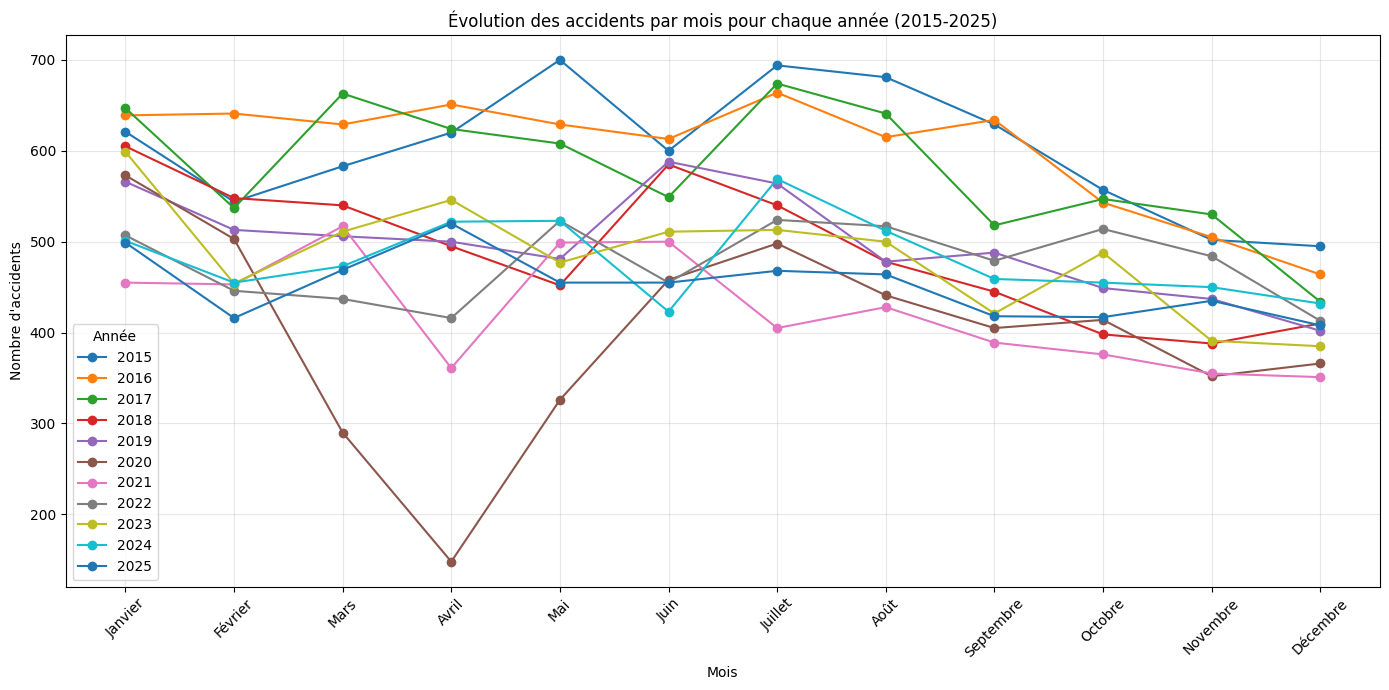

In [7]:
import matplotlib.pyplot as plt

ordre_mois = ["Janvier","Février","Mars","Avril","Mai","Juin",
              "Juillet","Août","Septembre","Octobre","Novembre","Décembre"]

pivot_accidents = df.pivot_table(index="Mois", columns="Annee", values="Accidents", aggfunc="sum").reindex(ordre_mois)

plt.figure(figsize=(14, 7))
for annee in pivot_accidents.columns:
    plt.plot(pivot_accidents.index, pivot_accidents[annee], marker="o", label=str(annee))

plt.title("Évolution des accidents par mois pour chaque année (2015-2025)")
plt.xlabel("Mois")
plt.ylabel("Nombre d'accidents")
plt.xticks(rotation=45)
plt.legend(title="Année")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Comparaison du profil mensuel entre les années

Après avoir étudié les saisons, cette représentation permet de comparer directement le nombre d’accidents pour chacun des mois et pour chacune des années.

L’objectif est de vérifier si les mêmes mois présentent régulièrement des niveaux élevés ou faibles. Lorsque les courbes suivent des profils similaires d’une année à l’autre, cela renforce l’hypothèse d’une composante saisonnière dans les accidents.

Cette visualisation permet également de distinguer les variations structurelles liées aux mois des variations exceptionnelles propres à certaines années.

Distribution mensuelle des accidents en 2020 :
           Accidents  Morts  Blesses
Mois                                
Janvier          573    108      780
Février          503    105      700
Mars             290     63      417
Avril            148     37      179
Mai              326     51      478
Juin             458     82      639
Juillet          498    100      733
Août             441     96      703
Septembre        405     66      523
Octobre          414     69      563
Novembre         352     74      532
Décembre         366     80      515

Mois avec le PLUS d'accidents : Janvier (573)
Mois avec le MOINS d'accidents : Avril (148)


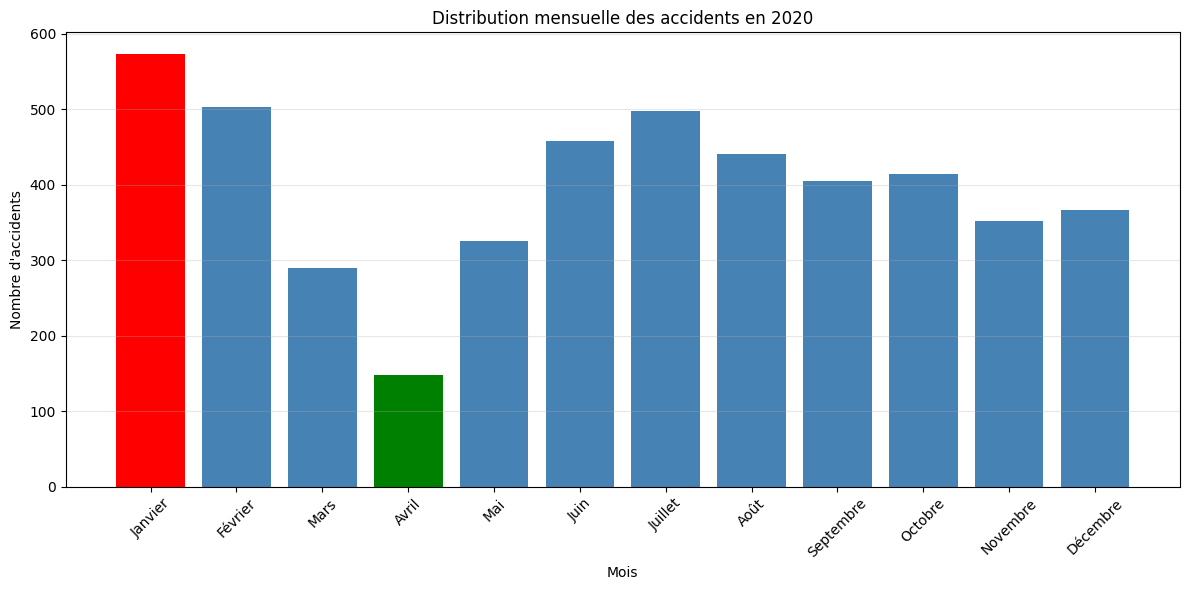

In [8]:
import matplotlib.pyplot as plt

ordre_mois = ["Janvier","Février","Mars","Avril","Mai","Juin",
              "Juillet","Août","Septembre","Octobre","Novembre","Décembre"]

df_2020 = df[df["Annee"] == 2020].set_index("Mois").reindex(ordre_mois)

print("Distribution mensuelle des accidents en 2020 :")
print(df_2020[["Accidents", "Morts", "Blesses"]])

mois_max = df_2020["Accidents"].idxmax()
mois_min = df_2020["Accidents"].idxmin()
print(f"\nMois avec le PLUS d'accidents : {mois_max} ({df_2020['Accidents'].max()})")
print(f"Mois avec le MOINS d'accidents : {mois_min} ({df_2020['Accidents'].min()})")

plt.figure(figsize=(12, 6))
couleurs = ["red" if m == mois_max else "green" if m == mois_min else "steelblue" for m in df_2020.index]
plt.bar(df_2020.index, df_2020["Accidents"], color=couleurs)

plt.title("Distribution mensuelle des accidents en 2020")
plt.xlabel("Mois")
plt.ylabel("Nombre d'accidents")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Zoom sur l’année 2020

L’année 2020 présente une rupture particulièrement visible dans l’évolution générale. Une analyse spécifique est donc réalisée afin d’identifier les mois à l’origine de cette baisse.

Les résultats montrent une diminution très importante à partir de **mars 2020**, avec un minimum en **avril (148 accidents)**, contre **573 en janvier**. Le niveau remonte ensuite progressivement à partir de mai et juin.

Cette évolution est compatible avec l’hypothèse d’un effet des restrictions de déplacement liées à la pandémie de Covid-19, notamment pendant la période de confinement. Cependant, les données utilisées ici sont uniquement mensuelles et ne permettent pas d’attribuer causalement toute la baisse au confinement : elles montrent surtout une rupture temporelle qui coïncide avec cette période. Une analyse avec des données journalières et les dates précises des restrictions permettrait d’étudier cette hypothèse plus rigoureusement.

Comparaison du nombre moyen d'accidents par jour (2020 exclue) :
      Mois du Ramadan  Accidents Ramadan  Accidents hors Ramadan  \
Annee                                                              
2015    18/06 - 17/07              640.6                  6585.4   
2016    06/06 - 05/07              617.9                  6609.1   
2017    27/05 - 24/06              537.3                  6434.7   
2018    16/05 - 14/06              506.3                  5377.7   
2019    06/05 - 03/06              462.2                  5509.8   
2021    13/04 - 12/05              409.8                  4679.2   
2022    02/04 - 01/05              419.0                  5296.0   
2023    23/03 - 20/04              512.4                  5283.6   
2024    11/03 - 09/04              477.0                  5297.0   
2025    01/03 - 30/03              453.9                  4970.1   

       Accidents/jour Ramadan  Accidents/jour hors Ramadan  \
Annee                                                   

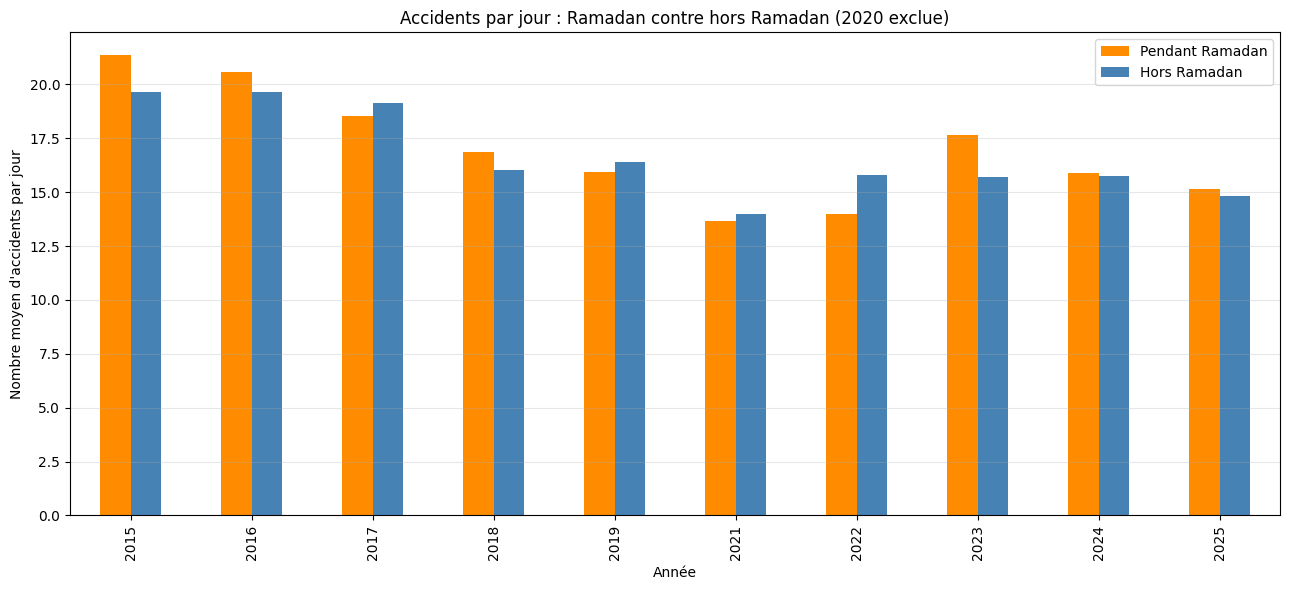

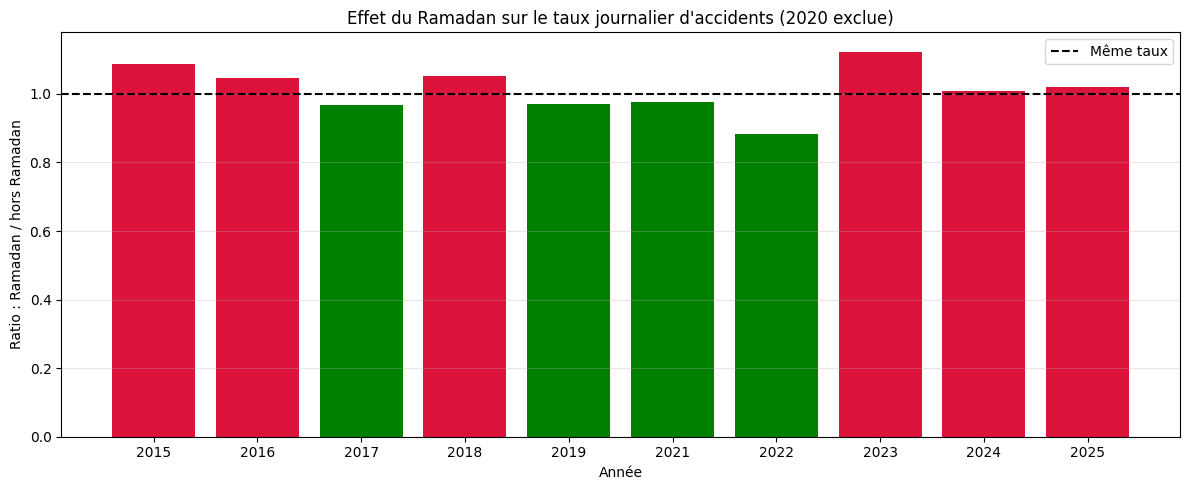

In [9]:
import calendar
from datetime import date
import matplotlib.pyplot as plt

# Dates du Ramadan : (premier jour, dernier jour)
RAMADAN_DATES = {
    2015: (date(2015, 6, 18), date(2015, 7, 17)),
    2016: (date(2016, 6, 6), date(2016, 7, 5)),
    2017: (date(2017, 5, 27), date(2017, 6, 24)),
    2018: (date(2018, 5, 16), date(2018, 6, 14)),
    2019: (date(2019, 5, 6), date(2019, 6, 3)),
    2021: (date(2021, 4, 13), date(2021, 5, 12)),
    2022: (date(2022, 4, 2), date(2022, 5, 1)),
    2023: (date(2023, 3, 23), date(2023, 4, 20)),
    2024: (date(2024, 3, 11), date(2024, 4, 9)),
    2025: (date(2025, 3, 1), date(2025, 3, 30)),
}

# 2020 est volontairement absente de l'analyse.
resultats = []

for annee, (debut, fin) in RAMADAN_DATES.items():
    df_annee = df[df["Annee"] == annee].copy()
    if df_annee.empty:
        continue

    accidents_ramadan = 0.0
    jours_ramadan = (fin - debut).days + 1

    # Estimation des accidents du Ramadan à partir des données mensuelles.
    # Chaque mois est pondéré par le nombre de jours communs avec le Ramadan.
    for _, ligne in df_annee.iterrows():
        mois = int(ligne["Mois_num"])
        jours_dans_mois = calendar.monthrange(annee, mois)[1]
        debut_mois = date(annee, mois, 1)
        fin_mois = date(annee, mois, jours_dans_mois)
        jours_communs = max(
            0,
            (min(fin, fin_mois) - max(debut, debut_mois)).days + 1,
        )
        accidents_ramadan += ligne["Accidents"] * jours_communs / jours_dans_mois

    total_accidents = df_annee["Accidents"].sum()
    jours_annee = 366 if calendar.isleap(annee) else 365
    jours_hors_ramadan = jours_annee - jours_ramadan
    accidents_hors_ramadan = total_accidents - accidents_ramadan

    taux_ramadan = accidents_ramadan / jours_ramadan
    taux_hors_ramadan = accidents_hors_ramadan / jours_hors_ramadan

    resultats.append({
        "Annee": annee,
        "Mois du Ramadan": f"{debut.strftime('%d/%m')} - {fin.strftime('%d/%m')}",
        "Accidents Ramadan": round(accidents_ramadan, 1),
        "Accidents hors Ramadan": round(accidents_hors_ramadan, 1),
        "Accidents/jour Ramadan": taux_ramadan,
        "Accidents/jour hors Ramadan": taux_hors_ramadan,
        "Ratio Ramadan / hors Ramadan": taux_ramadan / taux_hors_ramadan,
    })

df_ramadan = pd.DataFrame(resultats).set_index("Annee")

print("Comparaison du nombre moyen d'accidents par jour (2020 exclue) :")
print(df_ramadan.round(2))
print("\nInterprétation du ratio :")
print("- ratio > 1 : plus d'accidents par jour pendant le Ramadan")
print("- ratio < 1 : moins d'accidents par jour pendant le Ramadan")
print(f"\nRatio moyen : {df_ramadan['Ratio Ramadan / hors Ramadan'].mean():.2f}")

ax = df_ramadan[["Accidents/jour Ramadan", "Accidents/jour hors Ramadan"]].plot(
    kind="bar",
    figsize=(13, 6),
    color=["darkorange", "steelblue"],
)
ax.set_title("Accidents par jour : Ramadan contre hors Ramadan (2020 exclue)")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre moyen d'accidents par jour")
ax.legend(["Pendant Ramadan", "Hors Ramadan"])
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(
    df_ramadan.index.astype(str),
    df_ramadan["Ratio Ramadan / hors Ramadan"],
    color=["green" if ratio < 1 else "crimson" for ratio in df_ramadan["Ratio Ramadan / hors Ramadan"]],
)
plt.axhline(1, color="black", linestyle="--", label="Même taux")
plt.title("Effet du Ramadan sur le taux journalier d'accidents (2020 exclue)")
plt.xlabel("Année")
plt.ylabel("Ratio : Ramadan / hors Ramadan")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Exploration de l’effet potentiel du Ramadan

Une dernière hypothèse étudiée concerne un éventuel effet du Ramadan sur l’accidentologie. Pour chaque année disponible, les dates de début et de fin du Ramadan sont utilisées afin d’estimer le nombre d’accidents correspondant à cette période.

Comme les données disponibles sont mensuelles et non journalières, il est nécessaire d’estimer la part d’un mois correspondant au Ramadan. Le calcul suppose implicitement que les accidents sont répartis uniformément à l’intérieur de chaque mois, puis pondère chaque mois selon le nombre de jours communs avec la période du Ramadan.

Les taux journaliers estimés sont ensuite comparés entre la période du Ramadan et le reste de l’année. Les ratios obtenus varient selon les années : certains sont supérieurs à 1, d’autres inférieurs à 1, et le ratio moyen calculé est d’environ **1,01**.

Ainsi, avec cette méthode et ces données, **aucun effet clair et systématique du Ramadan ne peut être établi**. Cette conclusion doit toutefois être considérée avec prudence, car l’estimation repose sur une hypothèse forte d’uniformité des accidents à l’intérieur de chaque mois. Une base de données journalière permettrait de connaître directement le nombre d’accidents pendant chaque jour du Ramadan et hors Ramadan, et fournirait donc une comparaison beaucoup plus précise.

### Conclusion générale

L’analyse met en évidence plusieurs éléments importants dans l’évolution mensuelle de l’accidentologie en Tunisie sur la période 2015–2025 :

- une **tendance globale à la baisse** du nombre d’accidents sur la période ;
- une **saisonnalité visible**, avec une contribution particulièrement importante de l’été et, dans une moindre mesure, de l’hiver ;
- une répartition saisonnière qui se retrouve dans la plupart des années, ce qui suggère que le profil observé ne dépend pas uniquement du hasard d’une année particulière ;
- une **rupture très marquée en 2020**, avec une forte diminution des accidents à partir de mars et un minimum en avril, compatible avec la période des restrictions liées à la Covid-19 ;
- concernant le **Ramadan**, les résultats obtenus avec les données mensuelles ne permettent pas de mettre en évidence un effet systématique.

La principale limite de cette étude est donc la **granularité mensuelle des données**. Pour approfondir les conclusions, une base journalière permettrait notamment d’étudier plus précisément les effets du confinement, du Ramadan, des jours de la semaine, des conditions météorologiques et d’autres facteurs susceptibles d’influencer l’accidentologie.